In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Week2 복습과제**

**1. [ANN]**

**2. [CNN]**

- 데이터는 Week 1 과 같이 MNIST (0-9 숫자 분류) 데이터셋입니다.
- 이때, 우리의 복습과제에서는 0-4 숫자 분류를 위한 데이터 샘플만 사용할 예정입니다
- 아래 코드를 실행시켜 주세요

In [ ]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Subset
import random

# Tensor 변환을 위함 (함수 묶어두는 자료구조)
transform = transforms.Compose([
    transforms.ToTensor()
])

# MNIST 데이터셋 불러오기
train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = MNIST(root='./data', train=False, transform=transform, download=True)

# 무작위로 샘플 인덱스 선택 => label이 1~4인 인덱스 수집
train_indices = [i for i, label in enumerate(train_dataset.targets) if label in [0, 1, 2, 3, 4]]
test_indices = [i for i, label in enumerate(test_dataset.targets) if label in [0, 1, 2, 3, 4]]

# Subset을 사용하여 샘플링된 데이터셋 생성
train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)

# DataLoader 생성
batch_size = 64  # 배치 크기는 64로 설정 (batch_size를 다르게 실행해보셔도 좋습니다)
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.07MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 160kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.70MB/s]


In [ ]:
# 데이터셋 크기 확인을 위해 해당 셀을 실행시켜 주세요
print(f"Train dataset size: {len(train_subset)}")
print(f"Test dataset size: {len(test_subset)}")

Train dataset size: 30596
Test dataset size: 5139


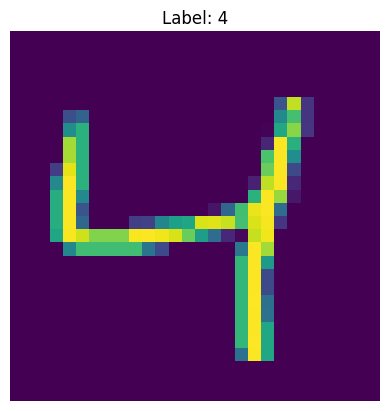

In [ ]:
# 데이터셋 중 하나의 이미지를 시각화해보기
import matplotlib.pyplot as plt
import numpy as np

# 데이터셋에서 하나의 샘플 가져오기
image, label = train_subset[1]

# 텐서를 NumPy 배열로 변환
image = image.numpy().squeeze()

# 이미지 출력
plt.imshow(image)  # 이미지 표시
plt.title(f"Label: {label}")  # 레이블 표시
plt.axis("off")  # 축 없애기
plt.show()

<a id="1"></a> <br>
## **1. ANN**

**인공 신경망 (ANN)**

>  로지스틱 회귀는 분류 문제에서 성능이 좋지만, 데이터의 비선형성이 증가하면 모델의 정확도가 감소합니다.

>  따라서, hidden lyaer 에 더 많은 비선형 함수를 추가시켜 모델의 복잡도를 증가시켜 봅시다. 😀

↪ **3개의 hidden layer를 쌓고 다양한 활성화 함수 ReLU, Tanh, ELU 사용해봅시다**


In [ ]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn

In [ ]:
# CPU/GPU 사용 지정
if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')

#### **ANN 모델 생성**

In [ ]:
# ANN Model
class ANNModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim): # 차원들
        super(ANNModel, self).__init__()

        # Linear function 1: 입력층 --> 은닉층  (입력 차원에서 숨겨진 계층으로)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Non-linearity 1 (ReLU 활성화 함수)
        self.relu1 = nn.ReLU()

        # Linear function 2: 은닉층 --> 은닉층  (숨겨진 계층을 한 번 더 통과)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 2 (Tanh 활성화 함수 사용)
        self.tanh2 = nn.Tanh()

        # Linear function 3: 은닉층 --> 은닉층  (추가 숨겨진 계층)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 3 (ELU 활성화 함수)
        self.elu3 = nn.ELU()

        # Linear function 4: 은닉층 --> 출력층  (마지막 출력층)
        self.fc4 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Linear function 1
        out = self.fc1(x)
        # Non-linearity 1
        out = self.relu1(out)

        # Linear function 2
        out = self.fc2(out)
        # Non-linearity 2
        out = self.tanh2(out)

        # Linear function 3
        out = self.fc3(out)
        # Non-linearity 3
        out = self.elu3(out)

        # Linear function 4
        out = self.fc4(out)  # 마지막 출력층
        return out

In [ ]:
# ANN 객체 생성
input_dim = 784  # 이미지 크기 (28x28)
hidden_dim = 150  # 하이퍼파라미터 (150으로 설정)
output_dim = 5  # 출력 클래스 개수 (label 0~4)

model = ANNModel(input_dim,hidden_dim,output_dim)
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss() # 다중분류에 적합한 손실함수를 선택해주세요 -> CEE

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

#### **ANN 모델 학습**

In [ ]:
# ANN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트

# 전체 학습
for epoch in range(10):

    # 배치 단위 학습 - train_loader에 설정해둔대로 돌아감
    for i, (images, labels) in enumerate(train_loader):

        # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
        train = images.view(-1, 784)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
        labels = labels  # 텐서 형태 유지 (텐서로.. 뽑아왔었음)

        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        # 모델을 이용해 예측값(outputs) 계산
        outputs = model(train).float()

        # 손실 계산
        # cross entropy loss를 사용해 예측값과 실제값 비교
        loss = loss_ftn(outputs, labels)

        # Backward propagation - 손실에 대한 기울기 계산
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            # 정확도 계산을 위한 변수 초기화
            correct = 0
            total = 0


            # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
            for images, labels in test_loader:

                test = images.view(-1, 784)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                # Forward
                # 예측값 계산
                outputs = model(test)

                # 예측값 중 가장 높은 값을 선택
                ## outputs: 모델이 각 클래스에 대해 계산한 점수를 담고 있음
                ## -> 각 샘플마다 예측한 결과 클래스를 선택해서 predicted에 넣음
                predicted = torch.max(outputs.data, 1)[1]

                # 총 샘플 개수
                total += len(labels)

                # 올바르게 예측한 개수
                correct += (predicted == labels).sum()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if count % 500 == 0:
            # 손실 및 정확도 출력
            print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))


Iteration: 500  Loss: 0.2550387680530548  Accuracy: 96.26386260986328 %
Iteration: 1000  Loss: 0.1300361305475235  Accuracy: 97.33411407470703 %
Iteration: 1500  Loss: 0.10721240937709808  Accuracy: 97.43140411376953 %
Iteration: 2000  Loss: 0.11871370673179626  Accuracy: 97.68437194824219 %
Iteration: 2500  Loss: 0.030661307275295258  Accuracy: 97.89842224121094 %
Iteration: 3000  Loss: 0.1293162703514099  Accuracy: 97.93733978271484 %
Iteration: 3500  Loss: 0.12184112519025803  Accuracy: 98.093017578125 %
Iteration: 4000  Loss: 0.03536703810095787  Accuracy: 98.40435791015625 %
Iteration: 4500  Loss: 0.15908309817314148  Accuracy: 98.48219299316406 %


#### **ANN 학습 결과**

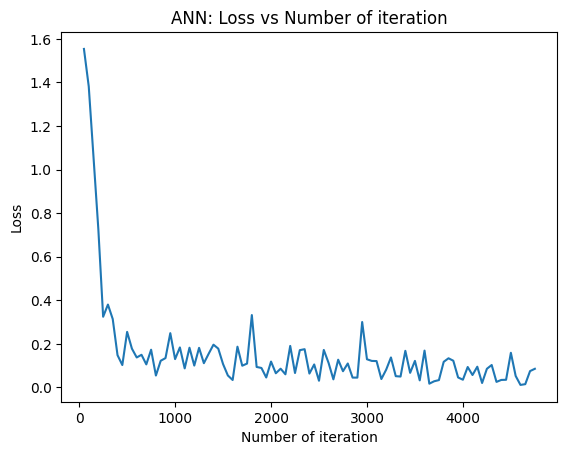

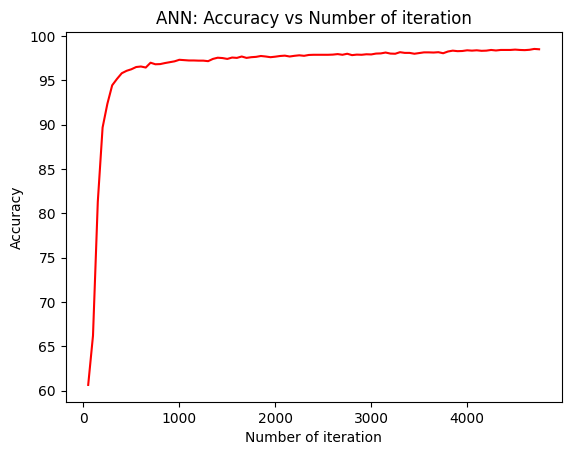

In [ ]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 시각화된 모델의 학습 결과를 해석해주세요.** 🤗



---
**[해석]**
- **Loss vs Number of Iteration**: 초반에는 손실 값이 1.6에 가까웠다가, 500 iterations 이후로 0.2, 1500 iterations 이후로는 대부분 0.1 이하의 손실 값을 유지하고 있다.
- **Accuracy vs Number of Iteration**: 초반에는 정확도가 60% 정도였다가, 학습을 진행시키면서 안정적으로 95% 이상, 이후 약 98%까지 정확도가 증가했다.

- 학습이 반복되면서 손실 값이 낮아지고 정확도가 증가했는데, 모델의 예측이 정답 labels와 점점 유사해졌기 때문이다.

- Loss 노이즈 이유? -> 배치로 나누어 학습시켰기 때문에 이에 따라 작은 규모의 노이즈가 생김

#### **ANN 최적의 하이퍼파라미터 찾기**

1️⃣ **실험 1: Hidden Dimension 최적값 찾기**
- hidden_dim 값을 50-200 사이 값들로 설정하고 모델을 학습
- 각 hidden_dim 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교




2️⃣ **실험 2: Learning Rate 최적값 찾기**

- learning_rate 값을 0.1-0.005 사이 값들로 설정하고 모델을 학습
- 각 learning_rate 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교



**⚠ 이때 epoch 값은 자유롭게 해주셔도 됩니다! **

In [ ]:
# 실험 1 hidden_dims=[50-200 사이 값들] 로 학습
hidden_dims = [50, 100, 150, 200]
results={} # 모든 dim에 대한 결과 저장

for hidden_dim in hidden_dims:
  print("[[ hidden_dim: {} ]]".format(hidden_dim))

  # ANN 객체 생성
  model = ANNModel(input_dim, hidden_dim, output_dim)
  loss_ftn = nn.CrossEntropyLoss()
  learning_rate = 0.02
  optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

  # 모델 학습 - 초기화
  count=0
  loss_list = []
  iteration_list=[]
  accuracy_list=[]

  # 전체 학습
  for epoch in range(10):
    for i, (images, labels) in enumerate(train_loader):
      train = images.view(-1,784)
      labels = labels # 텐서
      optimizer.zero_grad()

      # Forward
      outputs = model(train)
      loss = loss_ftn(outputs, labels)

      # Backward propagation
      loss.backward()
      optimizer.step()

      count+=1
      if count % 10 == 0: # iteration 10번마다 정확도 계산
        correct=0
        total=0

        # 테스트 데이터셋으로 정학도 확인
        for images, labels in test_loader:
          test = images.view(-1, 784)
          # Forward
          outputs = model(test)
          # 예측한 값 추출
          predicted = torch.max(outputs.data,1)[1]
          total+=len(labels)
          correct+=(predicted==labels).sum()

        accuracy = 100 * correct/float(total)
        loss_list.append(loss.item())
        iteration_list.append(count)
        accuracy_list.append(accuracy)

      if count % 200 == 0:
        print('Iteration: {} Loss: {} Accuracy: {}%'.format(count,loss.data, accuracy))

    results[hidden_dim]={
        "loss": loss_list,
        "iteration": iteration_list,
        "accuracy": accuracy_list
    }

[[ hidden_dim: 50 ]]
Iteration: 200 Loss: 0.7976515293121338 Accuracy: 81.94200897216797%
Iteration: 400 Loss: 0.26392701268196106 Accuracy: 94.0066146850586%
Iteration: 600 Loss: 0.134388267993927 Accuracy: 96.03035736083984%
Iteration: 800 Loss: 0.18634094297885895 Accuracy: 96.55574798583984%
Iteration: 1000 Loss: 0.056876931339502335 Accuracy: 96.86709594726562%
Iteration: 1200 Loss: 0.18976257741451263 Accuracy: 97.13951873779297%
Iteration: 1400 Loss: 0.08389768749475479 Accuracy: 97.39248657226562%
Iteration: 1600 Loss: 0.15196530520915985 Accuracy: 97.54816436767578%
Iteration: 1800 Loss: 0.06375374644994736 Accuracy: 97.52870178222656%
Iteration: 2000 Loss: 0.08157187700271606 Accuracy: 97.58708190917969%
Iteration: 2200 Loss: 0.10076795518398285 Accuracy: 97.7232894897461%
Iteration: 2400 Loss: 0.0326966866850853 Accuracy: 97.76220703125%
Iteration: 2600 Loss: 0.044182971119880676 Accuracy: 97.78166961669922%
Iteration: 2800 Loss: 0.12050208449363708 Accuracy: 97.801132202148

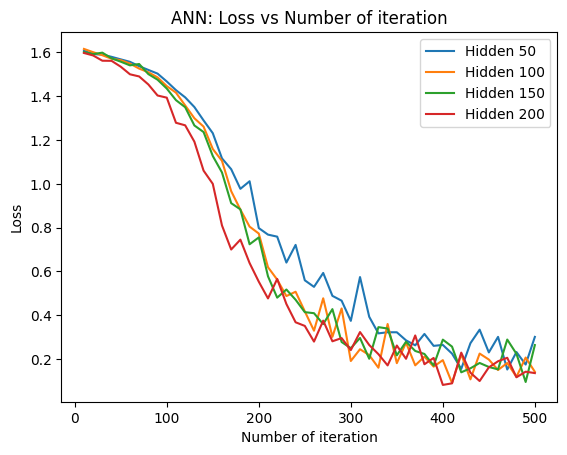

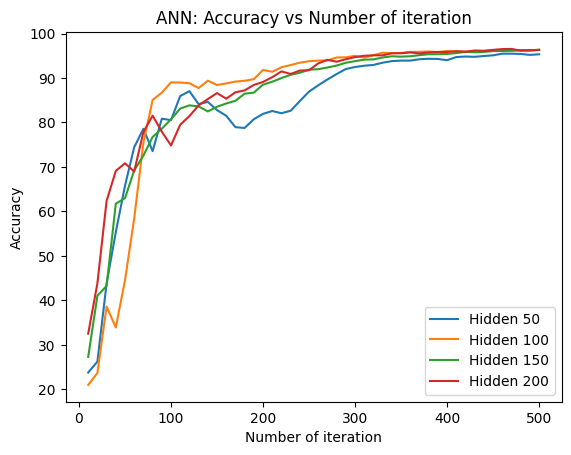

In [ ]:
# 실험 1 모델 학습 결과 시각화

# loss 시각화
for dim in hidden_dims:
  plt.plot(results[dim]["iteration"][:50],results[dim]["loss"][:50], label=f"Hidden {dim}")
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration")
plt.legend()
plt.show()

# accuracy 시각화
for dim in hidden_dims:
  plt.plot(results[dim]["iteration"][:50],results[dim]["accuracy"][:50], label=f"Hidden {dim}")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration")
plt.legend()
plt.show()

**해당 셀의 마크 다운을 풀고 hidden dimension 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
- hidden_dims = [50, 100, 150, 200] 으로 실험을 진행했고, 전체 결과를 관찰했을 때 모든 모델이 iteration이 어느 정도 증가하면 정확도가 98% 이상까지 도달했다.
- Number of iteration이 300 이상일 때부터는 모델들의 성능 차이가 그렇게 크지 않았다.
- hidden_dim=50 일 때 은닉층이 제일 얕아 Loss 감소와 Accuracy 증가가 제일 느리게 이루어졌고, hidden_dim=200 일 때 은닉층이 제일 깊어 학습이 빠르게 이루어졌다.

In [ ]:
# 실험 2 learning_rates=[0.1-0.005 사이 값들] 로 학습
learning_rates = [0.1, 0.05, 0.02, 0.005]
results={} # 모든 lr에 대한 결과 저장

for learning_rate in learning_rates:
  print("[[ learning_rate: {} ]]".format(learning_rate))

  # ANN 객체 생성
  hidden_dim = 150
  model = ANNModel(input_dim, hidden_dim, output_dim)
  loss_ftn = nn.CrossEntropyLoss()
  optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

  # 모델 학습 - 초기화
  count=0
  loss_list = []
  iteration_list=[]
  accuracy_list=[]

  # 전체 학습
  for epoch in range(10):
    for i, (images, labels) in enumerate(train_loader):
      train = images.view(-1,784)
      labels = labels # 텐서
      optimizer.zero_grad()

      # Forward
      outputs = model(train)
      loss = loss_ftn(outputs, labels)

      # Backward propagation
      loss.backward()
      optimizer.step()

      count+=1
      if count % 10 == 0: # iteration 10번마다 정확도 계산
        correct=0
        total=0

        # 테스트 데이터셋으로 정학도 확인
        for images, labels in test_loader:
          test = images.view(-1, 784)
          # Forward
          outputs = model(test)
          # 예측한 값 추출
          predicted = torch.max(outputs.data,1)[1]
          total+=len(labels)
          correct+=(predicted==labels).sum()

        accuracy = 100 * correct/float(total)
        loss_list.append(loss.item())
        iteration_list.append(count)
        accuracy_list.append(accuracy)

      if count % 200 == 0:
        print('Iteration: {} Loss: {} Accuracy: {}%'.format(count,loss.data, accuracy))

    results[learning_rate]={
        "loss": loss_list,
        "iteration": iteration_list,
        "accuracy": accuracy_list
    }

[[ learning_rate: 0.1 ]]
Iteration: 200 Loss: 0.14538541436195374 Accuracy: 97.08114624023438%
Iteration: 400 Loss: 0.1973702609539032 Accuracy: 97.17843627929688%
Iteration: 600 Loss: 0.19049818813800812 Accuracy: 97.60653686523438%
Iteration: 800 Loss: 0.18648366630077362 Accuracy: 98.05409240722656%
Iteration: 1000 Loss: 0.0681845098733902 Accuracy: 98.44327545166016%
Iteration: 1200 Loss: 0.03335075452923775 Accuracy: 98.59894561767578%
Iteration: 1400 Loss: 0.03297441080212593 Accuracy: 98.87137603759766%
Iteration: 1600 Loss: 0.022706737741827965 Accuracy: 98.85191345214844%
Iteration: 1800 Loss: 0.029809633269906044 Accuracy: 98.92975616455078%
Iteration: 2000 Loss: 0.0975155308842659 Accuracy: 98.69624328613281%
Iteration: 2200 Loss: 0.008508868515491486 Accuracy: 99.16326141357422%
Iteration: 2400 Loss: 0.04067808389663696 Accuracy: 99.20217895507812%
Iteration: 2600 Loss: 0.07943399250507355 Accuracy: 99.41622924804688%
Iteration: 2800 Loss: 0.028154078871011734 Accuracy: 99.

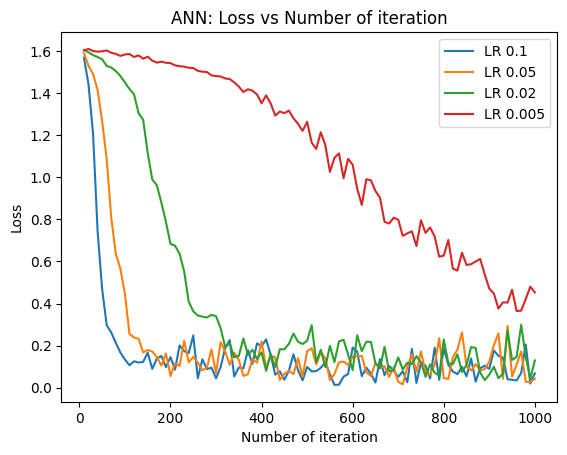

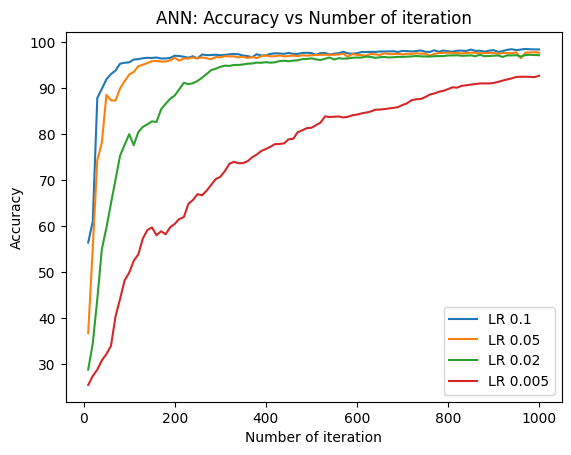

In [ ]:
# 실험 2 모델 학습 결과 시각화

# loss 시각화
for lr in learning_rates:
  plt.plot(results[lr]["iteration"][:100],results[lr]["loss"][:100], label=f"LR {lr}")
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration")
plt.legend()
plt.show()

# accuracy 시각화
for lr in learning_rates:
  plt.plot(results[lr]["iteration"][:100],results[lr]["accuracy"][:100], label=f"LR {lr}")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration")
plt.legend()
plt.show()

**해당 셀의 마크 다운을 풀고 learning rate 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
- learning rate 값은 모델의 학습 속도에 영향을 준다. 그래프를 보면 학습률을 0.1로 설정했을 때는 0.05로 설정했을 때보다 Loss 감소와 Accuracy 증가가 훨씬 빠르게 이루어졌음을 알 수 있다.
- lr=0.1일 때 iteration=200 에서 정확도가 97.08% 였는데, lr=0.05일 때는 iteration=3200 이 되어서야 정확도가 97.06% 에 도달했다.

<a id="1"></a> <br>
## **2. CNN**
> CNN은 이미지 분류에 적합한 모델로, kernel을 이용해 feature map을 생성합니다

**↪ 2개의 합성곱 계층을 쌓고, 활성화 함수로 ReLU를 사용하며,Max Pooling layer를 적용해봅시다.**

#### **CNN 모델 생성**

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim

# CNN Model 정의
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # 합성곱 계층 1 (Conv Layer 1)
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 1
        ## default: (stride=None, padding=0)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)  # kernel size를 2로 설정

        # 합성곱 계층 2 (Conv Layer 2)
        ## Layer 1 의 out_channels=16 -> Layer 2 의 in_channels
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2) # kernel size를 2로 설정

        # Fully Connected Layer
        ## Layer 2 output 32 -> FC input 32 => class 5 (0,1,2,3,4)
        self.fc1 = nn.Linear(512, 5)  # 입력 차원 및 출력 차원 지정

    def forward(self, x):
        # 합성곱 계층 1 + 활성화 함수
        out = self.cnn1(x)
        out = self.relu1(out)

        # Max Pooling 1
        out = self.maxpool1(out)

        # 합성곱 계층 2 + 활성화 함수
        out = self.cnn2(out)
        out = self.relu2(out)

        # Max Pooling 2
        out = self.maxpool2(out)

        # feature map을 flatten하게
        # print("out.type: ", out.type) -> Tensor
        out = out.view(out.size(0), -1)

        # 완전 연결 계층
        out = self.fc1(out)

        return out


In [36]:
# CNN 객체 생성
model = CNNModel()
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss()  # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
optimizer = optim.SGD(model.parameters(), lr=0.02)  # 학습률을 자유롭게 설정해주세요

#### **CNN 모델 학습**

In [37]:
# CNN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트
num_epochs = 20  # 학습할 에포크 수 설정 -> 자유롭게 설정해주셔도 됩니다

for epoch in range(num_epochs):
    running_loss = 0.0  # 에포크별 손실 초기화

    for images, labels in train_loader:
        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        outputs = model.forward(images)

        # 손실 계산
        loss = loss_ftn(outputs, labels)

        # Backward
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # 손실 누적
        running_loss += loss.item()
        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            correct = 0
            total = 0

            with torch.no_grad():  # 평가
                for images, labels in test_loader:
                    # 모델 예측 수행
                    outputs = model.forward(images)

                    # 가장 확률이 높은 클래스 선택
                    predicted = torch.max(outputs.data,1)[1]

                    # 총 샘플 수 및 올바른 예측 개수 누적
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

    # 매 에포크마다 평균 손실 출력
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

Epoch 1, Loss: 0.3250645783949558
Epoch 2, Loss: 0.10044803777573502
Epoch 3, Loss: 0.07623141166211606
Epoch 4, Loss: 0.06135697814340398
Epoch 5, Loss: 0.05145849458511631
Epoch 6, Loss: 0.04501424534469921
Epoch 7, Loss: 0.039726384502732526
Epoch 8, Loss: 0.035680229432528715
Epoch 9, Loss: 0.03240176212501426
Epoch 10, Loss: 0.029638287553219574
Epoch 11, Loss: 0.02793610259651893
Epoch 12, Loss: 0.026221621661769744
Epoch 13, Loss: 0.024684566879642073
Epoch 14, Loss: 0.02310159666250345
Epoch 15, Loss: 0.021939431075509813
Epoch 16, Loss: 0.020846279929314267
Epoch 17, Loss: 0.01948189478545471
Epoch 18, Loss: 0.019236712215618
Epoch 19, Loss: 0.01834261579793151
Epoch 20, Loss: 0.018767168084152203


#### **CNN 학습 결과**

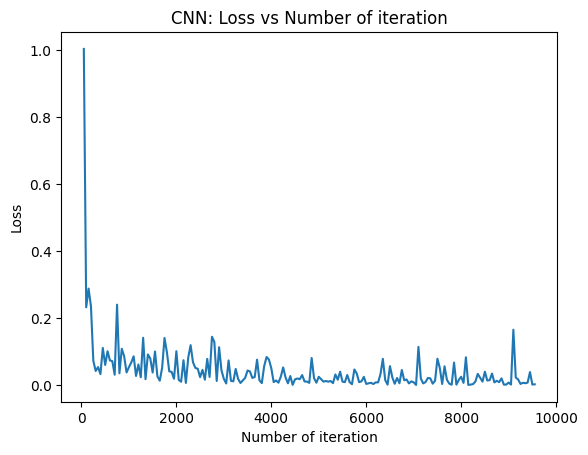

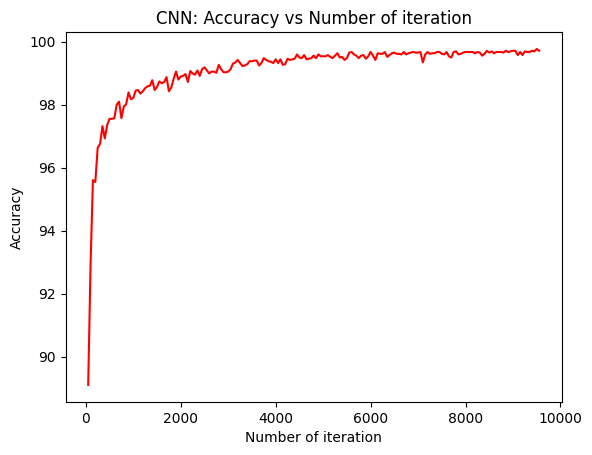

In [38]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("CNN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 MNIST 데이터셋에서 ANN, CNN의 학습 결과 비교와 함께 두 모델에 대해 각각 짧게 소개해주세요.** 🤗



---
**[답변]**
- ANN, CNN 둘 다 iteration에 따른 성능이 비슷하게 나왔다. 그러나 반복을 더 많이 했음에도 불구하고 CNN 모델을 학습시키는 데 걸리는 시간이 ANN보다 현저히 짧았다. 즉, CNN이 convolution을 이용해 이미지 데이터를 다루는 데 더 적합한 모델이라는 것을 관찰할 수 있었다.
- ANN: 입력층, 은닉층(여러 층일 수 있음), 출력층으로 이루어진 인공신경망. 위 ANN 모델은 linear afftine transformation을 수행하는 Linear 함수 4개와 활성화 함수 3개로 구성되었다.
- CNN: 합성곱층과 풀링층으로 이루어진 이미지 처리에 적합한 인공 신경망. 합성곱층에서 이미지의 특징을 추출 및 학습하고, 풀링층에서 추출한 특징을 모으고 강화한다. 위 CNN 모델은 합성곱층-활성화함수(렐루)-풀링층 이 두 번 쌓여있고, 마지막 결과 도출을 위해 Linear 함수까지 연결되어 있다.